# Biodiversity and Conservation Analysis in U.S. National Parks

## 1. Introduction

The U.S. National Park Service (NPS) plays a pivotal role in the preservation of North American biodiversity. This projects investigates the conservation profiles of 5541 species across four iconic parks: Yellowstone, Yosemite, Bryce and Great Smoky Mountains.

Using data-driven analysis, we aim to uncover patterns in species endangerment and determine if certain taxonomic groups face higher risks of extinction. By analyzing the different species along with their conservation status, we seek to provide insights into which species groups are at the greatest conservation risk. Specifically, this study evaluates the distribution of conservation statuses, tests the statistical significance of the association between the species category and its protection status, and identifies the most frequently observed species within each park.

We will seek to answer the following questions:
* What is the distribution of `conservation_status` for species?
* Are certain type of species more likely to be endangered?
* Are differences between species and their conservation status significant?
* Which species were spotted the most at each park?

The structure of this study is as follows:
1. Introduction
2. Exploratory Data Analysis (EDA):
   1. Loading the data.
   2. Initial data inspection.
   3. Handling missing data and duplicates.
3. Analysis
4. Results

## 2. Exploratory Data Analysis

### A. Loading the data

To begin, we import the libraries that we will use throughout this project. 

In [1]:
 # Import libraries for the project
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

We load the datasets into DataFrames. In the next section, we will perform an initial inspection of the data.

In [2]:
# Load datasets
species = pd.read_csv('species_info.csv')
observations = pd.read_csv('observations.csv')

### B. Initial Data Inspection

We have been given two datasets contained in CSV files. The file 'species_info.csv' contains data about different species and their conservation status. The other file, 'observations.csv', holds recorded sightings of different species at several national parks for a 7-day period. Let's begin inspecting the file 'species_info.csv' read in as a dataframe called species.

In [3]:
# Display the first few rows of the DataFrame to get a glimpse of the data
print('First 5 rows of the DataFrame:')
species.head()

First 5 rows of the DataFrame:


,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


The dataset **species** contains four columns:
* category - class of animal.
* scientific_name - the scientific name of each species.
* common_name - the common names of each species.
* conservation_status - each species’ current conservation status.

As previously mentioned, the dataset contains 4 columns, each of which is a variable, and 5824 rows, each of which is an observation representing a species.

The column names are correct, so there is no need to adjust them. Each column has an object data type. This seems accurate given that all four variables are categorical. There are no missing values in the columns 'category', 'scientific_name' and 'common_name'; however, 'conservation_status' column contains 5633 missing values. When analyzing duplicate values, we didn't find any rows duplicated; however, there are 283 rows with a duplicate value in the "scientific_name' column. This means that some species are duplicated in the dataset. We will address this issue in the next section to avoid potential bias in our analysis.

In [4]:
# Print a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Information:")
print(species.info())

# Display number of rows and columns of the DataFrame.
print(f'\nThis dataset contains {species.shape[0]} rows and {species.shape[1]} columns.')

# Display number of duplicated values.
rows_duplicated = species.duplicated().sum()
print(f'\nThis dataset contains {rows_duplicated} rows duplicated.')

scientific_name_duplicated = species.duplicated(subset = 'scientific_name').sum()
print(f'\nThis dataset contains {scientific_name_duplicated} rows with a duplicate value in the column "scientific_name".')

# Missing values per column
print('\nNumber of missing values per column:')
print(species.isnull().sum())


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
None

This dataset contains 5824 rows and 4 columns.

This dataset contains 0 rows duplicated.

This dataset contains 283 rows with a duplicate value in the column "scientific_name".

Number of missing values per column:
category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64


Exploring in more depth the variable 'scientific_name', we find that there are 5,541 unique species. These species are classified in seven categories: Mammal, Bird, Reptile, Amphibian, Fishm, Vascular Plant and Nonvascular Plant.

For the variable 'conservation status', we find that there are four categories: 
* In Recovery: formerly endangered, but currently neither in danger of extinction throughout all or a significant portion of its range.
* Species of Concern: declining or appear to be in need of conservation.
* Threatened: vulnerable to endangerment in the near future.
* Endangered: seriously at risk of extinction.

As mentioned above, 5,633 observations have missing data for the conservation status variable, we will address this issue in the following section.

In [5]:
# Species
unique_species = species['scientific_name'].nunique()
print(f'Number of unique species in the DataFrame: {unique_species}')

# Categories
num_categories = species['category'].nunique()
print(f'\nNumber of categories: {num_categories}')
print('\nCategories:')
print(species['category'].unique())

# Conservation Status
print('\nCategories for conservation status:')
print(species['conservation_status'].unique())

Number of unique species in the DataFrame: 5541

Number of categories: 7

Categories:
['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']

Categories for conservation status:
[nan 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']


Similarly, we will perform a initial data inspection of the **observations** dataset. This dataset contains three columns:
* scientific_name: the scientific name of each species
* park_name: Park where species were found
* observations: the number of times each species was observed at park

In [6]:
# Display the first few rows of the DataFrame to get a glimpse of the data
print('First 5 rows of the DataFrame:')
observations.head()

First 5 rows of the DataFrame:


,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


This dataset contains 23296 rows and 3 columns. Each row represents the number of times a given species at a given park was observed over a period of 7 days. The 3 columns are the variables described above. There is no missing values in this dataset. We find that there are 15 rows with duplicate values, and when considering the subset of columns 'scientific_name' and 'park_name', 1132 rows are duplicated. This could mean that observations of certain species at certain parks were recorded in more than one row and we could aggregate the data. We will address this issue in the following section. 

Finally, we can observe that this dataset contains data of 4 National Parks: Great Smoky Mountains National Park, Yosemite National Park, Bryce National Park, and Yellowstone National Park.

In [35]:
# Print a concise summary of the DataFrame, including data types and non-null values
print("\nDataFrame Information:")
print(observations.info())

# Display number of rows and columns of the DataFrame.
print(f'\nThis dataset contains {observations.shape[0]} rows and {observations.shape[1]} columns.')

# Display number of duplicated values.
rows_duplicated = observations.duplicated().sum()
print(f'\nThis dataset contains {rows_duplicated} rows duplicated.')

species_park_duplicated = observations.duplicated(subset = ['scientific_name', 'park_name']).sum()
print(f'\nThis dataset contains {species_park_duplicated} rows with a duplicate value when considering the columns "scientific_name" and "park_name".')

# Missing values per column
print('\nNumber of missing values per column:')
print(observations.isnull().sum())

# Number of parks
print('\nNational Parks included in the DataFrame:')
print(observations['park_name'].unique())


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB
None

This dataset contains 23296 rows and 3 columns.

This dataset contains 15 rows duplicated.

This dataset contains 1132 rows with a duplicate value when considering the columns "scientific_name" and "park_name".

Number of missing values per column:
scientific_name    0
park_name          0
observations       0
dtype: int64

National Parks included in the DataFrame:
['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']


### C. Handling missing data and duplicates

As we discussed in the previous section, the **species** dataset contains 5,633 missing values in the conservation status variable. This most likely means that those species are not in danger, and therefore, the conservation status variable shows a missing value. We will fill these NaN values with the category "No Intervention".

In [7]:
# Fill NaN with 'No Intervention' category
species['conservation_status'] = species['conservation_status'].fillna('No Intervention')
species['conservation_status'].value_counts()

conservation_status
No Intervention       5633
Species of Concern     161
Endangered              16
Threatened              10
In Recovery              4
Name: count, dtype: int64

Regarding the duplicate values, we saw in the previous section that 283 rows contain a duplicate value in the 'scientific_name' column. This means that some species are counted more than once. For example, Castor canadensis and Canis lupus, among others, are species with more than one row of data (see table below). To solve this issue, we will use the pandas groupby method along with custom aggregation functions. The custom functions will ensure to keep all unique common names and mantain the most serious conservation status for each species.

In [8]:
# Top ten species with the largest number of duplicate values.
print('Top ten species with the largest number of duplicate values')
print(species['scientific_name'].value_counts().head(10))

# Rows of species with duplicate values
print('\nCastor canadensis\' rows:')
print(species[species['scientific_name'] == 'Castor canadensis'])
print('\nCanis lupus\' rows:')
print(species[species['scientific_name'] == 'Canis lupus'])

Top ten species with the largest number of duplicate values
scientific_name
Castor canadensis        3
Canis lupus              3
Hypochaeris radicata     3
Columba livia            3
Puma concolor            3
Streptopelia decaocto    3
Holcus lanatus           3
Myotis lucifugus         3
Procyon lotor            3
Setaria viridis          2
Name: count, dtype: int64

Castor canadensis' rows:
     category    scientific_name             common_names conservation_status
49     Mammal  Castor canadensis  American Beaver, Beaver     No Intervention
3050   Mammal  Castor canadensis          American Beaver     No Intervention
4475   Mammal  Castor canadensis                   Beaver     No Intervention

Canis lupus' rows:
     category scientific_name     common_names conservation_status
8      Mammal     Canis lupus        Gray Wolf          Endangered
3020   Mammal     Canis lupus  Gray Wolf, Wolf         In Recovery
4448   Mammal     Canis lupus  Gray Wolf, Wolf          Endangered


In [9]:
# Remove duplicate values method
# 1. Define Conservation Status Priority (Lower number = More Serious)
status_priority = {
    'Endangered': 0,
    'Threatened': 1,
    'Species of Concern': 2,
    'In Recovery': 3,
    'No Intervention': 4
}

# 2. Define Custom Aggregation Functions
def aggregate_unique_names(series):
    """Splits strings by comma, removes duplicates, and joins them back."""
    all_names = set()
    for name_str in series.dropna():
        # Split by comma and strip whitespace from each name
        parts = [n.strip() for n in name_str.split(',')]
        all_names.update(parts)
    return ", ".join(sorted(list(all_names)))

def get_most_serious_status(series):
    """Returns the status with the highest priority (lowest rank number)."""
    # Map statuses to their rank; default to 99 for unknown statuses
    return series.loc[series.map(lambda x: status_priority.get(x, 99)).idxmin()]

# 4. Group and Aggregate
species = species.groupby('scientific_name').agg({
    'category': 'first', # categories stay the same for the same scientific name
    'common_names': aggregate_unique_names,
    'conservation_status': get_most_serious_status
}).reset_index()


Now we have a clean species dataset with no duplicate values that we can use for our analysis.

In [10]:
# Display number of duplicated values.
rows_duplicated = species.duplicated().sum()
print(f'\nThis dataset contains {rows_duplicated} rows duplicated.')

scientific_name_duplicated = species.duplicated(subset = 'scientific_name').sum()
print(f'\nThis dataset contains {scientific_name_duplicated} rows with a duplicate value in the column "scientific_name".')


This dataset contains 0 rows duplicated.

This dataset contains 0 rows with a duplicate value in the column "scientific_name".


Before moving to the analysis section, we noticed that the **observations** dataset contains 15 rows with duplicate values, and when considering the subset of columns 'scientific_name' and 'park_name', 1132 rows are duplicated. Given that the observations could have been recorded in multiple rows for the same species and park, we will not remove the 15 rows with duplicate values, however, we will aggregate the data so that each row contains information for a unique 'scientific_name' - 'park_name' pair. 

For example, the species 'Agrostis capillaris' will have only one row for observations at the Bryce National Park with 208 observations after the data aggregation.

In [11]:
# Rows with duplicate values we want to aggregate.
observations[observations.duplicated(subset = ['scientific_name', 'park_name'], keep = False)]\
.sort_values(['scientific_name', 'park_name']).head(2)

,scientific_name,park_name,observations
3993,Agrostis capillaris,Bryce National Park,103
4864,Agrostis capillaris,Bryce National Park,105


In [12]:
# Group by scientific_name and park_name
observations = observations.groupby(['scientific_name', 'park_name'])['observations'].sum().reset_index()

# Review the clean dataset
print(observations[observations['scientific_name'] == 'Agrostis capillaris'].head(1))

         scientific_name            park_name  observations
416  Agrostis capillaris  Bryce National Park           208


## 3. Analysis

### A. Distribution of conservation_status for species

There are 5,541 species represented in the dataset, which are classified into 7 categories. The most frequent category is vascular plants, with 4,262 species. Birds and mammals are the largest animal categories, with 488 and 176 species, respectively.

One hundred and seventy-nine species, which represents 3.2% of the total, are at some level of risk. More specifically, 151 are species of concern, 15 endangered, 10 threatened and 3 in recovery.

Of the 151 species of concern, birds are the most represented category, with 68 species declining or that appear to be in need of conservation, followed by vascular plants and mammals, with 43 and 22 species, respectively.

Regarding endangered species, which are at serious risk of extinction, 6 are mammals, 4 birds, 3 fishes, 1 amphibian and 1 vascular plant. Threatened species are also present in several categories, 4 are fishes, followed by amphibians, mammals and vascular plants, with 2 species each category. Finally, 3 species of fish are currently in recovery.

In [13]:
# Number of species by conservation status.
species['conservation_status'].value_counts()

conservation_status
No Intervention       5362
Species of Concern     151
Endangered              15
Threatened              10
In Recovery              3
Name: count, dtype: int64

category             Amphibian  Bird  Fish  Mammal  Nonvascular Plant  \
conservation_status                                                     
Endangered                   1     4     3       6                  0   
In Recovery                  0     3     0       0                  0   
Species of Concern           4    68     4      22                  5   
Threatened                   2     0     4       2                  0   

category             Reptile  Vascular Plant  
conservation_status                           
Endangered                 0               1  
In Recovery                0               0  
Species of Concern         5              43  
Threatened                 0               2  


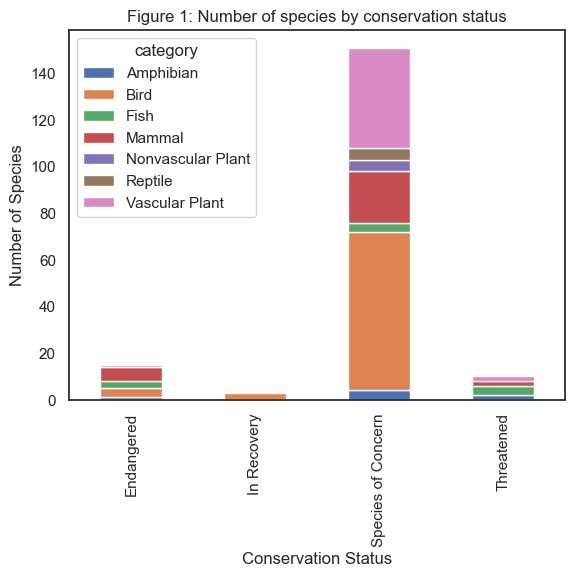

In [38]:
# Filter dataset on species that are protected
species_risk = species[species['conservation_status'] != 'No Intervention']

# Create a cross tabulation of category and conservation status
col_order = ['Endangered', 'Threatened', 'Species of Concern', 'In Recovery']
table_1 = pd.crosstab(species_risk['conservation_status'], species_risk['category'])
print(table_1)

# Create Table 1 and a stacked bar chart to visualize the relationship between both variables
table_1.plot(kind = 'bar', stacked = True)
plt.xlabel('Conservation Status')
plt.ylabel('Number of Species')
plt.title('Figure 1: Number of species by conservation status')
plt.show()

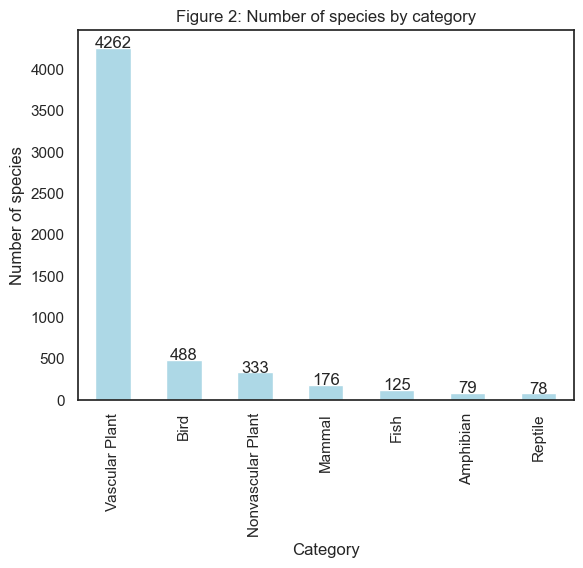

<Figure size 640x480 with 0 Axes>

In [39]:
# Distribution of species by category
cat_count = species['category'].value_counts().reset_index()

# Generate bar plot
cat_count.plot(x = 'category', y = 'count', kind = 'bar', color = 'lightblue', legend = False)

x = cat_count['category']
y = cat_count['count']

def add_labels(x, y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha='center')
add_labels(x, y)

plt.title('Figure 2: Number of species by category')
plt.ylabel('Number of species')
plt.xlabel('Category')
plt.show()
plt.clf()


### B. Are certain type of species more likely to be endangered?

In this section we want to understand if some species are more likely to be endangered. First, we create the variable 'is_protected', a categorical variable with the value 'Yes' if the species is at some level of risk, and 'No' otherwise. Based on this variable, we define the rate of protection for each species category. 

As we can see in the chart below, 17.05 percent of mammals have some level of protection, followed closely by birds, with a 15.37 percent of species at risk. Nonvascular and vascular plants are the species with the lowest rate of protection, both below 2 percent.

In [16]:
# Create 'is_protected' variable
species['is_protected'] = np.where(species['conservation_status'] == 'No Intervention', 'No', 'Yes')

# Table 2: protection rate by category
table_2 = round(pd.crosstab(species['category'], species['is_protected'], normalize = 'index') * 100, 2)\
.sort_values(by = 'Yes', ascending = False)
table_2

is_protected,No,Yes
category,,
Mammal,82.95,17.05
Bird,84.63,15.37
Amphibian,91.14,8.86
Fish,91.20,8.80
Reptile,93.59,6.41
Nonvascular Plant,98.50,1.50
Vascular Plant,98.92,1.08


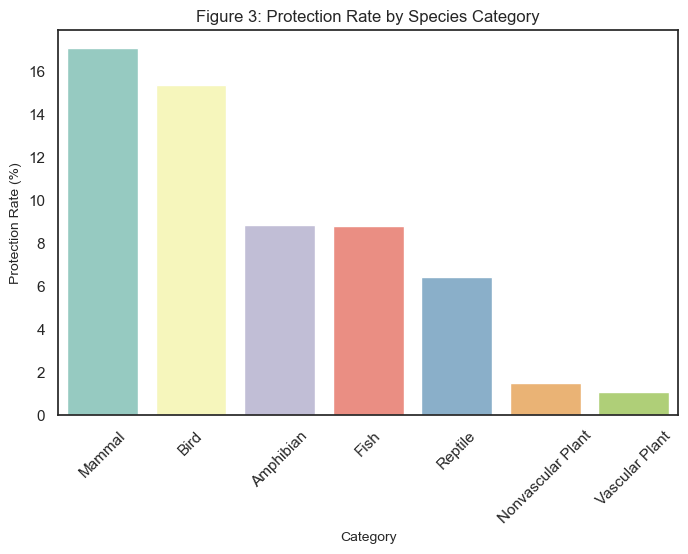

<Figure size 640x480 with 0 Axes>

In [41]:
# Chart for the protection rate by species category

sns.set_theme(style = 'white')
plt.figure(figsize = (8, 5))

ax = sns.barplot(data = table_2, x = 'category', hue = 'category', y = 'Yes', palette = 'Set3', legend = False)

plt.title('Figure 3: Protection Rate by Species Category', fontsize = 12)
plt.xlabel('Category', fontsize = 10)
plt.ylabel('Protection Rate (%)', fontsize = 10)
plt.xticks(rotation = 45)
plt.show()
plt.clf()

### C. Are differences between species and their conservation status significant?

From the chart above it can be observed that some species appear to be at higher risk than others, however, we want to test if these differences are significant. To do this, the most appropiate statistical method is the **Chi-Square Test of Independence** that will help us determine whether there is a significant association between `category` (the type of species) and `is_protected` (whether it is at risk or not).

* **Null Hypothesis** ($H_0$): There is no association between the species category and its protection status. This would means that the "risk" or protection rate is the same across all categories.

* **Alternative Hypothesis** ($H_0$): There is a significant association between the species category and its protection status. This would mean that the "risk" varies across categories.

The results from the Chi-Square Test show that the p-value is almost zero, which is below the 0.05 significance level. Based on this result we can reject the null hypothesis. This would mean that species are not all at the same level of conservation risk, and some categories are significantly more (or less) likely to be protected than others.

In [18]:
# Define the contingency table of frequencies
contingency_freq = pd.crosstab(species['category'], species['is_protected'])

# Compute the Chi-Square statistic
chi2, pval, dof, expected = chi2_contingency(contingency_freq)
print(f'P-value: {pval}')
print(f'\nChi-Square statistic: {chi2}')

P-value: 5.146759135430123e-89

Chi-Square statistic: 426.66729690562795


### D. Which species were spotted the most at each park?

To investigate this question, we will merge both datasets (species and observations) to get a database of species sightings in four U.S. National Parks along with other variables including category, common names, conservation_status and whether the species is protected or not.

The largest number of observations was recorded in Yellowstone National Park, with around 1.4 million, followed by Yosemite National Park with 0.86 million. The smallest parks in terms of observations are Bryce National Park and Great Smoky Mountains National Park, with fewer than 0.6 million observations each.

Regarding observations by species category, we can see that the largest number of observed species correspond to vascular plants. Observations of vascular plants in each park exceed those of the other six categories combined (Figure 4). 

When we focus on animal species, we find that they represent 17 percent of the total species observed, the remaining 83 percent are plants. Among animals, birds are the most observed (51 percent) followed by mammals (21 percent) and fish (12 percent). It is worth noting that the proportion of each category in the total number of species observed is similar across the different national parks (Figure 5 and 6).



In [143]:
# Merge both datasets
full_data = observations.merge(species, on = 'scientific_name', how = 'left')

In [99]:
# Table 3: observations by species category and park.
table_3 = full_data.groupby(['park_name', 'category'])['observations'].sum().unstack()
table_3

category,Amphibian,Bird,Fish,Mammal,Nonvascular Plant,Reptile,Vascular Plant
park_name,,,,,,,
Bryce National Park,7380,51647,12423,20550,32992,7950,443083
Great Smoky Mountains National Park,5707,37728,9206,15012,24857,5691,333619
Yellowstone National Park,19440,127251,30574,50795,83021,19554,1112927
Yosemite National Park,11444,76207,18615,30339,49783,11483,665461


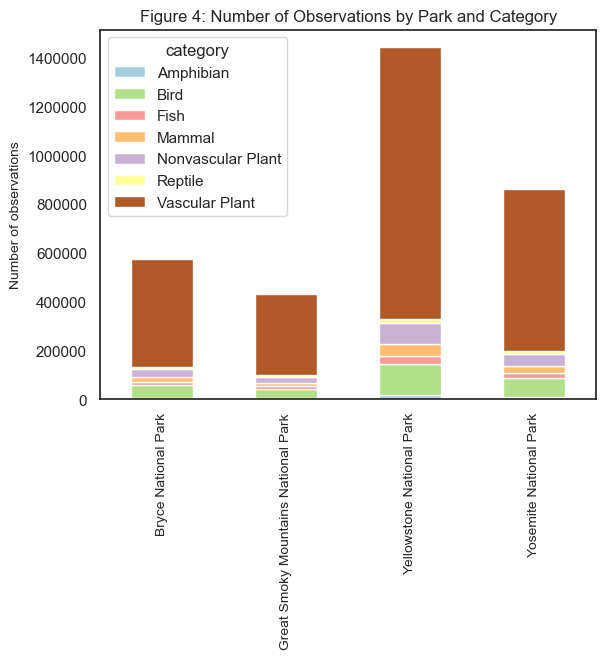

<Figure size 640x480 with 0 Axes>

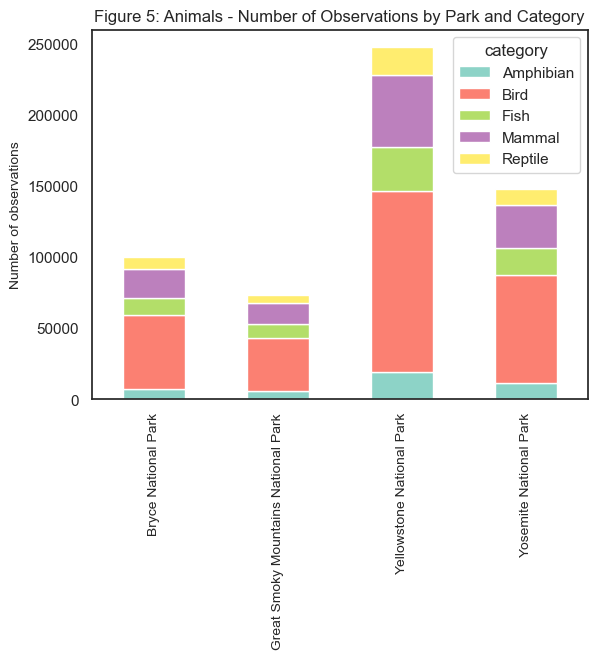

<Figure size 640x480 with 0 Axes>

In [100]:
# Figure 4: Number of Observations by Park and Category
table_3.plot(kind = 'bar', stacked = True, colormap = 'Paired')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Figure 4: Number of Observations by Park and Category')
plt.xlabel('')
plt.ylabel('Number of observations', fontsize = 10)
plt.xticks(fontsize = 10)
plt.show()
plt.clf()

# Figure 5: Animals - Number of Observations by Park and Category
table_4 = table_3.drop(columns = ['Vascular Plant', 'Nonvascular Plant'])
ax = table_4.plot(kind = 'bar', stacked = True, colormap = 'Set3')
plt.title('Figure 5: Animals - Number of Observations by Park and Category')
plt.xlabel('')
plt.ylabel('Number of observations', fontsize = 10)
plt.xticks(fontsize = 10)
plt.show()
plt.clf()

In [101]:
# Table 5: animals - observations by species category and park.
table_5 = table_3.drop(columns = ['Vascular Plant', 'Nonvascular Plant'])
table_5['Total'] = table_5.sum(axis = 1)
print('Table 5: animals - observations by species category and park')
print(table_5)

# Table 6: animals - observations by species category and park, in percentage of total
table_6 = round((table_5.div(table_5['Total'], axis = 0)) *100,1)
print('\nTable 6: animals - observations by species category and park, in percentage of total')
print(table_6)

Table 5: animals - observations by species category and park
category                             Amphibian    Bird   Fish  Mammal  \
park_name                                                               
Bryce National Park                       7380   51647  12423   20550   
Great Smoky Mountains National Park       5707   37728   9206   15012   
Yellowstone National Park                19440  127251  30574   50795   
Yosemite National Park                   11444   76207  18615   30339   

category                             Reptile   Total  
park_name                                             
Bryce National Park                     7950   99950  
Great Smoky Mountains National Park     5691   73344  
Yellowstone National Park              19554  247614  
Yosemite National Park                 11483  148088  

Table 6: animals - observations by species category and park, in percentage of total
category                             Amphibian  Bird  Fish  Mammal  Reptile  \
park_

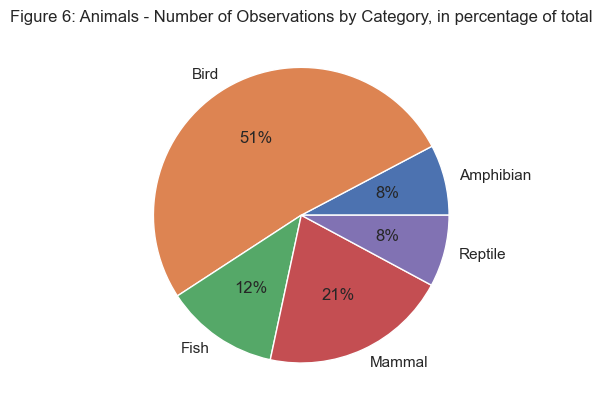

<Figure size 640x480 with 0 Axes>

In [120]:
# Figure 6: proportion of each category in the total number of animal species observed
figure_6 = full_data[(full_data['category'] != 'Vascular Plant') & (full_data['category'] != 'Nonvascular Plant')]
figure_6 = figure_6.groupby('category')['observations'].sum()
figure_6.plot(kind = 'pie', autopct = '%0.0f%%')
plt.title('Figure 6: Animals - Number of Observations by Category, in percentage of total')
plt.xlabel('')
plt.ylabel('')
plt.show()
plt.clf()

Among animal species, we will analyze **mammals** in more detail because they are a species widely observed in national parks; around 21 percent of the animals observed are mammals, and they are also the category with the higher protection rate at 17.05%. These are the main findings:
* *Puma concolor*, also known as Puma or Mountain Lion, is the most observed species in Yellowstone and Bryce National Parks. This animal is also widely observed in Yosemite and Great Smoky Mountains National Parks, ranking third in the list of most observed mammals.
* *Castor canadiensis*, commonly called beaver, is the most observed in Yosemite National Park. This animal is also frequently seen in the other national parks, consistently ranking among the three most observed mammals.
* *Procyon lotor*, usually called raccoon, is the most frequently observed mammal in Great Smoky Mountains National Park. As with the previous cases, it is also widely seen in the other national parks.
* Regarding *protected species*, we can see in Figure 7 that Myotis lucifugus, commonly known as little brown bat, is widespread in all four national parks. Bats are the only protected mammals that appear in the top 10 of most observed species in all four parks. As we can expect, the vast majority of species widely observed are not protected.

![foto1](./most_observed_mammals.png)

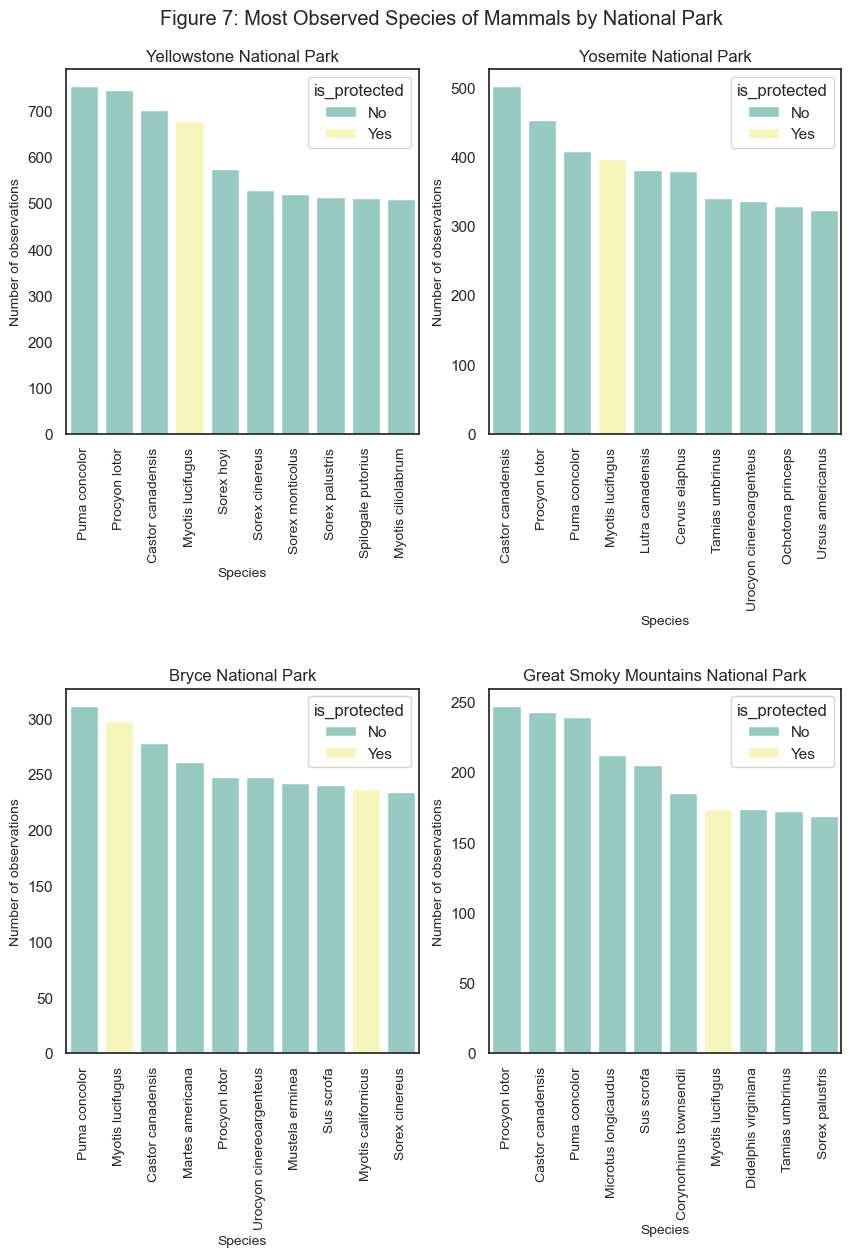

<Figure size 640x480 with 0 Axes>

In [142]:
# Figure 7: Most Observed Species of Mammals by National Park

national_parks = ['Yellowstone National Park', 'Yosemite National Park', 'Bryce National Park',
                  'Great Smoky Mountains National Park']
sub_full_data = []

for park in national_parks:
    park_data = full_data[(full_data['park_name'] == park) & (full_data['category'] == 'Mammal')]
    park_data = park_data.groupby(['scientific_name']).agg({'observations' : 'sum',
                                        'common_names' : 'first', 'category':'first',
                                       'is_protected' : 'first'}).sort_values(by = 'observations', ascending = False).reset_index().head(10)
    sub_full_data.append(park_data)

plt.subplots(2, 2, figsize=(10, 12))
plt.suptitle('Figure 7: Most Observed Species of Mammals by National Park')
plt.subplots_adjust(hspace = 0.7, top = 0.93)

i = range(4)
for i in range(4):
    plt.subplot( 2, 2, i + 1)
    sns.barplot(data = sub_full_data[i], x = 'scientific_name', hue = 'is_protected', y = 'observations', palette = 'Set3', legend = True)
    plt.xticks(rotation = 90, fontsize = 10)
    plt.title(national_parks[i], fontsize = 12)
    plt.xlabel('Species', fontsize = 10)
    plt.ylabel('Number of observations', fontsize = 10)

plt.show()
plt.clf()

## 4. Results: Biodiversity and Conservation Analysis

This study analyzed the conservation status and observation patterns of 5,541 species across four U.S. National Parks. By integrating species taxonomy with sighting data, we identified clear patterns in extinction risk and regional distribution.

### 1. Conservation Distribution and Risk Factors
While the vast majority of species are currently classified as "No Intervention", **3.2% (179 species)** are at some level of risk.

* **Species of Concern:** Birds are the most represented in this category (68 species), suggesting a widespread decline in avian populations.

* **Endangered:** Mammals and birds face the highest intensity of risk, accounting for the majority of species facing immediate extinction threats.

### 2. Statistical Significance of Protection Status
To determine if certain types of species are inherently more vulnerable, a **Chi-Square Test of Independence** was conducted.

* **Findings:** With a p-value near zero, we rejected the null hypothesis, confirming that **protection status is significantly associated with species category.**

* **Key Insight:** Mammals and birds have significantly higher protection rates (17.05% and 15.37% respectively) compared to vascular and nonvascular plants, which both maintain protection rates below 2%.

### 3. Park Observations and Regional Trends
The analysis of observation data across the four parks revealed a consistent ecological profile despite differences in park size and total sightings. The proportion of each category in the total number of species observed is similar across the different national parks.

* **Volume:** Yellowstone National Park recorded the highest activity (1.4M observations), while Bryce and Great Smoky Mountains saw the lowest (under 0.6M).

* **Biodiversity Balance:** Across all parks, plants dominate the landscape, accounting for **83% of all observations.** Among animals, birds are the most frequently sighted (51%), followed by mammals (21%).

### 4. Mammal Case Study: Observation vs. Protection
A deeper dive into mammals highlighted a contrast between commonality and conservation need:

* **Common Sightings:** The Puma (Puma concolor), Beaver (Castor canadiensis), and Raccoon (Procyon lotor) are the most ubiquitous mammals across all parks.

* **The "Protected" Exception:** Most frequently observed species are not at risk. However, the **Little Brown Bat** (Myotis lucifugus) stands out as a unique case—it is the only protected mammal that consistently ranks in the "Top 10" most observed mammals across all four parks, indicating a widespread but vulnerable population.

### Conclusion
The data suggests that while plants make up the bulk of the National Park biomass, **animal species—specifically mammals and birds—require a disproportionate amount of conservation intervention.** The statistically significant disparity in protection rates confirms that conservation efforts are currently, and perhaps necessarily, focused on these high-risk animal categories.